In [2]:
import os

print(os.getcwd())

C:\Users\leap


In [3]:
import os
import sys

scrapers_path = r"C:\Users\leap\Documents\GitHub\Appex-Asset-Suite\data_pipeline\scrapers"

if scrapers_path not in sys.path:
    sys.path.insert(0, scrapers_path)

print(scrapers_path in sys.path)

True


In [4]:
from base import BaseAppexScraper

print("BaseAppexScraper успешно импортирован")

BaseAppexScraper успешно импортирован


In [5]:
from autoScraper import AutoAppexScraper

print("AutoAppexScraper успешно импортирован")

AutoAppexScraper успешно импортирован


In [6]:
scraper = AutoAppexScraper()
print("Scraper создан:", scraper)

Scraper создан: <autoScraper.AutoAppexScraper object at 0x000002C5A1161FD0>


In [8]:
import time
import requests
from bs4 import BeautifulSoup

from base import BaseAppexScraper


class AutoAppexScraper(BaseAppexScraper):
    """Парсер премиальных автомобилей с Kolesa.kz."""

    ASSET_TYPE = "AUTO"

    BRANDS = [
        "mercedes-benz",
        "porsche",
        "maserati"
    ]

    MAX_PAGES = 10

    def run_scraper(self) -> list:

        headers = {
            "User-Agent": "Mozilla/5.0"
        }

        raw_cars = []

        for brand in self.BRANDS:

            print(f"\n========== {brand.upper()} ==========")

            for page in range(1, self.MAX_PAGES + 1):

                if page == 1:
                    url = f"https://kolesa.kz/cars/{brand}/"
                else:
                    url = f"https://kolesa.kz/cars/{brand}/?page={page}"

                response = requests.get(url, headers=headers)

                if response.status_code != 200:
                    print(f"Ошибка {response.status_code}")
                    break

                soup = BeautifulSoup(response.text, "html.parser")

                cards = soup.find_all("div", class_="a-list__item")

                if len(cards) == 0:
                    print(f"Страница {page}: объявлений больше нет.")
                    break

                print(f"Страница {page}: найдено {len(cards)} карточек")

                for card in cards:

                    title = card.find("h5", class_="a-card__title")
                    price = card.find("span", class_="a-card__price")
                    image = card.find("img")

                    title_text = title.get_text(strip=True) if title else ""

                    price_text = price.get_text(strip=True) if price else ""
                    price_text = (
                        price_text
                        .replace("₸", "")
                        .replace("\xa0", "")
                        .replace(" ", "")
                        .replace(",", "")
                    )

                    try:
                        price_value = int(price_text)
                    except:
                        price_value = 0

                    image_url = image["src"] if image else ""

                    raw_cars.append({
                        "title": title_text,
                        "price": price_value,
                        "roi": 0.0,
                        "image_url": image_url
                    })

                time.sleep(1)

        print(f"\nДо очистки: {len(raw_cars)}")

        cleaned_cars = []

        for car in raw_cars:

            if not car["title"]:
                continue

            if car["price"] <= 0:
                continue

            if not car["image_url"]:
                continue

            cleaned_cars.append(car)

        print(f"После очистки: {len(cleaned_cars)}")

        formatted_cars = []

        for car in cleaned_cars:

            formatted_car = self.format_to_db_payload(
                raw_item=car,
                asset_type=self.ASSET_TYPE
            )

            formatted_cars.append(formatted_car)

        print(f"Готово для БД: {len(formatted_cars)}")

        return formatted_cars

In [9]:
cars = scraper.run_scraper()

print("Всего автомобилей:", len(cars))


========== MERCEDES-BENZ ==========
Страница 1: найдено 25 карточек
Страница 2: найдено 25 карточек
Страница 3: найдено 25 карточек
Страница 4: найдено 25 карточек
Страница 5: найдено 25 карточек
Страница 6: найдено 25 карточек
Страница 7: найдено 25 карточек
Страница 8: найдено 25 карточек
Страница 9: найдено 25 карточек
Страница 10: найдено 25 карточек

========== PORSCHE ==========
Страница 1: найдено 25 карточек
Страница 2: найдено 25 карточек
Страница 3: найдено 25 карточек
Страница 4: найдено 25 карточек
Страница 5: найдено 25 карточек
Страница 6: найдено 25 карточек
Страница 7: найдено 25 карточек
Страница 8: найдено 25 карточек
Страница 9: найдено 25 карточек
Страница 10: найдено 25 карточек

========== MASERATI ==========
Страница 1: найдено 25 карточек
Страница 2: найдено 10 карточек
Страница 3: объявлений больше нет.

До очистки: 535
После очистки: 427
Готово для БД: 427
Всего автомобилей: 427


In [10]:
print(cars[:3])

[{'tenant_id': 'Appex_Main', 'asset_type': 'AUTO', 'title': 'Mercedes-Benz E 200', 'price_kzt': 11000000.0, 'price_usd': 20370.37, 'year': None, 'predicted_roi': 0.0, 'image_url': 'https://kolesa-photos.kcdn.online/webp/8b/8b032864-198b-4123-99d4-a26c25a843a5/4-160x120.jpg', 'created_at': '2026-08-10T08:42:22.955472'}, {'tenant_id': 'Appex_Main', 'asset_type': 'AUTO', 'title': 'Mercedes-Benz G 500', 'price_kzt': 12000000.0, 'price_usd': 22222.22, 'year': None, 'predicted_roi': 0.0, 'image_url': 'https://kolesa-photos.kcdn.online/webp/33/333c058d-e0a4-4779-9ad1-a1df5894d68a/2-160x120.jpg', 'created_at': '2026-08-10T08:42:22.955510'}, {'tenant_id': 'Appex_Main', 'asset_type': 'AUTO', 'title': 'Mercedes-Benz V 250 Avantgarde', 'price_kzt': 37890000.0, 'price_usd': 70166.67, 'year': None, 'predicted_roi': 0.0, 'image_url': 'https://kolesa-photos.kcdn.online/webp/1d/1d422a11-3f9d-4f28-8649-a26ba485dda6/5-160x120.jpg', 'created_at': '2026-08-10T08:42:22.955532'}]


In [11]:
print(cars[0].keys())

dict_keys(['tenant_id', 'asset_type', 'title', 'price_kzt', 'price_usd', 'year', 'predicted_roi', 'image_url', 'created_at'])


In [12]:
print("Количество автомобилей:", len(cars))
print()
print("Первая запись:")
print(cars[0])

Количество автомобилей: 427

Первая запись:
{'tenant_id': 'Appex_Main', 'asset_type': 'AUTO', 'title': 'Mercedes-Benz E 200', 'price_kzt': 11000000.0, 'price_usd': 20370.37, 'year': None, 'predicted_roi': 0.0, 'image_url': 'https://kolesa-photos.kcdn.online/webp/8b/8b032864-198b-4123-99d4-a26c25a843a5/4-160x120.jpg', 'created_at': '2026-08-10T08:42:22.955472'}


In [13]:
print()
print("Поля записи:")
print(cars[0].keys())


Поля записи:
dict_keys(['tenant_id', 'asset_type', 'title', 'price_kzt', 'price_usd', 'year', 'predicted_roi', 'image_url', 'created_at'])


In [14]:
import pandas as pd

df = pd.DataFrame(cars)

print("Размер таблицы:", df.shape)
display(df.head())

Размер таблицы: (427, 9)


,tenant_id,asset_type,title,price_kzt,price_usd,year,predicted_roi,image_url,created_at
0,Appex_Main,AUTO,Mercedes-Benz E 200,11000000.0,20370.37,None,0.0,https://kolesa-photos.kcdn.online/webp/8b/8b03...,2026-08-10T08:42:22.955472
1,Appex_Main,AUTO,Mercedes-Benz G 500,12000000.0,22222.22,None,0.0,https://kolesa-photos.kcdn.online/webp/33/333c...,2026-08-10T08:42:22.955510
2,Appex_Main,AUTO,Mercedes-Benz V 250 Avantgarde,37890000.0,70166.67,None,0.0,https://kolesa-photos.kcdn.online/webp/1d/1d42...,2026-08-10T08:42:22.955532
3,Appex_Main,AUTO,Mercedes-Benz E 300,19200000.0,35555.56,None,0.0,https://kolesa-photos.kcdn.online/webp/21/2132...,2026-08-10T08:42:22.955550
4,Appex_Main,AUTO,Mercedes-Benz E 350,7500000.0,13888.89,None,0.0,https://kolesa-photos.kcdn.online/webp/bc/bc6e...,2026-08-10T08:42:22.955569


In [15]:
print(df.columns.tolist())

['tenant_id', 'asset_type', 'title', 'price_kzt', 'price_usd', 'year', 'predicted_roi', 'image_url', 'created_at']


In [16]:
print("Минимальная цена:", df["price_usd"].min())
print("Максимальная цена:", df["price_usd"].max())
print("Медианная цена:", df["price_usd"].median())
print("Количество:", len(df))

Минимальная цена: 925.93
Максимальная цена: 412962.96
Медианная цена: 26851.85
Количество: 427


In [17]:
import pandas as pd

df = pd.DataFrame(cars)

print("Количество записей:", len(df))
display(df.head())

Количество записей: 427


,tenant_id,asset_type,title,price_kzt,price_usd,year,predicted_roi,image_url,created_at
0,Appex_Main,AUTO,Mercedes-Benz E 200,11000000.0,20370.37,None,0.0,https://kolesa-photos.kcdn.online/webp/8b/8b03...,2026-08-10T08:42:22.955472
1,Appex_Main,AUTO,Mercedes-Benz G 500,12000000.0,22222.22,None,0.0,https://kolesa-photos.kcdn.online/webp/33/333c...,2026-08-10T08:42:22.955510
2,Appex_Main,AUTO,Mercedes-Benz V 250 Avantgarde,37890000.0,70166.67,None,0.0,https://kolesa-photos.kcdn.online/webp/1d/1d42...,2026-08-10T08:42:22.955532
3,Appex_Main,AUTO,Mercedes-Benz E 300,19200000.0,35555.56,None,0.0,https://kolesa-photos.kcdn.online/webp/21/2132...,2026-08-10T08:42:22.955550
4,Appex_Main,AUTO,Mercedes-Benz E 350,7500000.0,13888.89,None,0.0,https://kolesa-photos.kcdn.online/webp/bc/bc6e...,2026-08-10T08:42:22.955569


In [18]:
benchmark = (
    df.groupby("title")["price_usd"]
      .median()
      .reset_index()
      .rename(columns={"price_usd": "supplier_price"})
)

display(benchmark.head(20))

,title,supplier_price
0,Maserati Ghibli,67685.185
1,Maserati GranCabrio Folgore,231481.480
2,Maserati GranCabrio Trofeo,243333.330
3,Maserati GranTurismo,34629.630
4,Maserati Grecale,92407.410
5,Maserati Grecale Trofeo,115185.190
6,Maserati Levante,82870.370
7,Maserati MC20 Cielo,218518.520
8,Maserati Quattroporte,87037.040
9,Mercedes-Benz 190,1481.480


In [19]:
df = df.merge(
    benchmark,
    on="title",
    how="left"
)

display(
    df[
        ["title", "price_usd", "supplier_price"]
    ].head(20)
)

,title,price_usd,supplier_price
0,Mercedes-Benz E 200,20370.37,11759.260
1,Mercedes-Benz G 500,22222.22,28240.740
2,Mercedes-Benz V 250 Avantgarde,70166.67,108518.520
3,Mercedes-Benz E 300,35555.56,9907.405
4,Mercedes-Benz E 350,13888.89,13888.890
5,Mercedes-Benz E 320,6111.11,6481.480
6,Mercedes-Benz G 63 AMG,342592.59,187870.375
7,Mercedes-Benz S 500,10185.19,10185.190
8,Mercedes-Benz GLE Coupe 450 AMG,40740.74,61481.480
9,Mercedes-Benz E 350,17592.59,13888.890


In [20]:
df["hidden_margin_currency"] = (
    df["price_usd"] - df["supplier_price"]
)

df["hidden_margin_percent"] = (
    df["hidden_margin_currency"]
    / df["supplier_price"]
    * 100
)

display(
    df[
        [
            "title",
            "price_usd",
            "supplier_price",
            "hidden_margin_currency",
            "hidden_margin_percent"
        ]
    ].head(20)
)

,title,price_usd,supplier_price,hidden_margin_currency,hidden_margin_percent
0,Mercedes-Benz E 200,20370.37,11759.260,8611.110,73.228332
1,Mercedes-Benz G 500,22222.22,28240.740,-6018.520,-21.311481
2,Mercedes-Benz V 250 Avantgarde,70166.67,108518.520,-38351.850,-35.341295
3,Mercedes-Benz E 300,35555.56,9907.405,25648.155,258.878637
4,Mercedes-Benz E 350,13888.89,13888.890,0.000,0.000000
5,Mercedes-Benz E 320,6111.11,6481.480,-370.370,-5.714281
6,Mercedes-Benz G 63 AMG,342592.59,187870.375,154722.215,82.355834
7,Mercedes-Benz S 500,10185.19,10185.190,0.000,0.000000
8,Mercedes-Benz GLE Coupe 450 AMG,40740.74,61481.480,-20740.740,-33.734939
9,Mercedes-Benz E 350,17592.59,13888.890,3703.700,26.666638


In [21]:
def margin_category(percent):

    if percent >= 20:
        return "Высокая наценка"

    elif percent > 0:
        return "Небольшая наценка"

    else:
        return "Ниже рынка"


df["margin_category"] = (
    df["hidden_margin_percent"]
    .apply(margin_category)
)

print(df["margin_category"].value_counts())

margin_category
Ниже рынка           255
Высокая наценка      123
Небольшая наценка     49
Name: count, dtype: int64


In [22]:
top_overpriced = (
    df[
        df["hidden_margin_percent"] > 0
    ]
    .sort_values(
        "hidden_margin_percent",
        ascending=False
    )
    .head(10)
)

display(
    top_overpriced[
        [
            "title",
            "price_usd",
            "supplier_price",
            "hidden_margin_currency",
            "hidden_margin_percent"
        ]
    ]
)

,title,price_usd,supplier_price,hidden_margin_currency,hidden_margin_percent
135,Mercedes-Benz S 500,109259.26,10185.19,99074.07,972.726773
327,Porsche Cayenne,138888.89,15740.74,123148.15,782.352990
132,Mercedes-Benz G 500,175925.93,28240.74,147685.19,522.950850
272,Porsche Cayenne,90740.74,15740.74,75000.00,476.470611
382,Porsche Cayenne,83333.33,15740.74,67592.59,429.411768
369,Porsche Cayenne,83333.33,15740.74,67592.59,429.411768
219,Porsche Cayenne,83333.33,15740.74,67592.59,429.411768
388,Porsche Cayenne,83333.33,15740.74,67592.59,429.411768
255,Porsche Cayenne,77777.78,15740.74,62037.04,394.117684
296,Porsche Cayenne,74074.07,15740.74,58333.33,370.588232


In [23]:
import pandas as pd

df = pd.DataFrame(cars)

print("Количество записей:", len(df))
print("Колонки:", df.columns.tolist())

display(df.head())

Количество записей: 427
Колонки: ['tenant_id', 'asset_type', 'title', 'price_kzt', 'price_usd', 'year', 'predicted_roi', 'image_url', 'created_at']


,tenant_id,asset_type,title,price_kzt,price_usd,year,predicted_roi,image_url,created_at
0,Appex_Main,AUTO,Mercedes-Benz E 200,11000000.0,20370.37,None,0.0,https://kolesa-photos.kcdn.online/webp/8b/8b03...,2026-08-10T08:42:22.955472
1,Appex_Main,AUTO,Mercedes-Benz G 500,12000000.0,22222.22,None,0.0,https://kolesa-photos.kcdn.online/webp/33/333c...,2026-08-10T08:42:22.955510
2,Appex_Main,AUTO,Mercedes-Benz V 250 Avantgarde,37890000.0,70166.67,None,0.0,https://kolesa-photos.kcdn.online/webp/1d/1d42...,2026-08-10T08:42:22.955532
3,Appex_Main,AUTO,Mercedes-Benz E 300,19200000.0,35555.56,None,0.0,https://kolesa-photos.kcdn.online/webp/21/2132...,2026-08-10T08:42:22.955550
4,Appex_Main,AUTO,Mercedes-Benz E 350,7500000.0,13888.89,None,0.0,https://kolesa-photos.kcdn.online/webp/bc/bc6e...,2026-08-10T08:42:22.955569


In [24]:
benchmark = (
    df.groupby("title")["price_usd"]
      .median()
      .reset_index()
      .rename(columns={"price_usd": "supplier_price"})
)

print("Количество моделей с benchmark:", len(benchmark))

display(benchmark.head(20))

Количество моделей с benchmark: 103


,title,supplier_price
0,Maserati Ghibli,67685.185
1,Maserati GranCabrio Folgore,231481.480
2,Maserati GranCabrio Trofeo,243333.330
3,Maserati GranTurismo,34629.630
4,Maserati Grecale,92407.410
5,Maserati Grecale Trofeo,115185.190
6,Maserati Levante,82870.370
7,Maserati MC20 Cielo,218518.520
8,Maserati Quattroporte,87037.040
9,Mercedes-Benz 190,1481.480


In [25]:
df = df.merge(
    benchmark,
    on="title",
    how="left"
)

print("Количество автомобилей:", len(df))
print("Количество с benchmark:", df["supplier_price"].notna().sum())
print("Количество без benchmark:", df["supplier_price"].isna().sum())

display(
    df[
        ["title", "price_usd", "supplier_price"]
    ].head(20)
)

Количество автомобилей: 427
Количество с benchmark: 427
Количество без benchmark: 0


,title,price_usd,supplier_price
0,Mercedes-Benz E 200,20370.37,11759.260
1,Mercedes-Benz G 500,22222.22,28240.740
2,Mercedes-Benz V 250 Avantgarde,70166.67,108518.520
3,Mercedes-Benz E 300,35555.56,9907.405
4,Mercedes-Benz E 350,13888.89,13888.890
5,Mercedes-Benz E 320,6111.11,6481.480
6,Mercedes-Benz G 63 AMG,342592.59,187870.375
7,Mercedes-Benz S 500,10185.19,10185.190
8,Mercedes-Benz GLE Coupe 450 AMG,40740.74,61481.480
9,Mercedes-Benz E 350,17592.59,13888.890


In [26]:
df["hidden_margin_currency"] = (
    df["price_usd"] - df["supplier_price"]
)

df["hidden_margin_percent"] = (
    df["hidden_margin_currency"]
    / df["supplier_price"]
    * 100
)

display(
    df[
        [
            "title",
            "price_usd",
            "supplier_price",
            "hidden_margin_currency",
            "hidden_margin_percent"
        ]
    ].head(20)
)

,title,price_usd,supplier_price,hidden_margin_currency,hidden_margin_percent
0,Mercedes-Benz E 200,20370.37,11759.260,8611.110,73.228332
1,Mercedes-Benz G 500,22222.22,28240.740,-6018.520,-21.311481
2,Mercedes-Benz V 250 Avantgarde,70166.67,108518.520,-38351.850,-35.341295
3,Mercedes-Benz E 300,35555.56,9907.405,25648.155,258.878637
4,Mercedes-Benz E 350,13888.89,13888.890,0.000,0.000000
5,Mercedes-Benz E 320,6111.11,6481.480,-370.370,-5.714281
6,Mercedes-Benz G 63 AMG,342592.59,187870.375,154722.215,82.355834
7,Mercedes-Benz S 500,10185.19,10185.190,0.000,0.000000
8,Mercedes-Benz GLE Coupe 450 AMG,40740.74,61481.480,-20740.740,-33.734939
9,Mercedes-Benz E 350,17592.59,13888.890,3703.700,26.666638


In [27]:
def classify_margin(percent):
    if percent < 0:
        return "Ниже рынка"
    elif percent <= 20:
        return "Небольшая наценка"
    else:
        return "Высокая наценка"


df["margin_category"] = df["hidden_margin_percent"].apply(
    classify_margin
)

print(df["margin_category"].value_counts())

display(
    df[
        [
            "title",
            "price_usd",
            "supplier_price",
            "hidden_margin_currency",
            "hidden_margin_percent",
            "margin_category"
        ]
    ].head(20)
)

margin_category
Ниже рынка           173
Небольшая наценка    131
Высокая наценка      123
Name: count, dtype: int64


,title,price_usd,supplier_price,hidden_margin_currency,hidden_margin_percent,margin_category
0,Mercedes-Benz E 200,20370.37,11759.260,8611.110,73.228332,Высокая наценка
1,Mercedes-Benz G 500,22222.22,28240.740,-6018.520,-21.311481,Ниже рынка
2,Mercedes-Benz V 250 Avantgarde,70166.67,108518.520,-38351.850,-35.341295,Ниже рынка
3,Mercedes-Benz E 300,35555.56,9907.405,25648.155,258.878637,Высокая наценка
4,Mercedes-Benz E 350,13888.89,13888.890,0.000,0.000000,Небольшая наценка
5,Mercedes-Benz E 320,6111.11,6481.480,-370.370,-5.714281,Ниже рынка
6,Mercedes-Benz G 63 AMG,342592.59,187870.375,154722.215,82.355834,Высокая наценка
7,Mercedes-Benz S 500,10185.19,10185.190,0.000,0.000000,Небольшая наценка
8,Mercedes-Benz GLE Coupe 450 AMG,40740.74,61481.480,-20740.740,-33.734939,Ниже рынка
9,Mercedes-Benz E 350,17592.59,13888.890,3703.700,26.666638,Высокая наценка


In [28]:
display(
    df[
        [
            "title",
            "price_usd",
            "supplier_price",
            "hidden_margin_currency",
            "hidden_margin_percent",
            "margin_category"
        ]
    ].head(10)
)

,title,price_usd,supplier_price,hidden_margin_currency,hidden_margin_percent,margin_category
0,Mercedes-Benz E 200,20370.37,11759.260,8611.110,73.228332,Высокая наценка
1,Mercedes-Benz G 500,22222.22,28240.740,-6018.520,-21.311481,Ниже рынка
2,Mercedes-Benz V 250 Avantgarde,70166.67,108518.520,-38351.850,-35.341295,Ниже рынка
3,Mercedes-Benz E 300,35555.56,9907.405,25648.155,258.878637,Высокая наценка
4,Mercedes-Benz E 350,13888.89,13888.890,0.000,0.000000,Небольшая наценка
5,Mercedes-Benz E 320,6111.11,6481.480,-370.370,-5.714281,Ниже рынка
6,Mercedes-Benz G 63 AMG,342592.59,187870.375,154722.215,82.355834,Высокая наценка
7,Mercedes-Benz S 500,10185.19,10185.190,0.000,0.000000,Небольшая наценка
8,Mercedes-Benz GLE Coupe 450 AMG,40740.74,61481.480,-20740.740,-33.734939,Ниже рынка
9,Mercedes-Benz E 350,17592.59,13888.890,3703.700,26.666638,Высокая наценка


In [29]:
summary = (
    df.groupby("margin_category")
      .agg(
          cars_count=("title", "count"),
          total_hidden_margin=("hidden_margin_currency", "sum"),
          average_margin_percent=("hidden_margin_percent", "mean")
      )
      .reset_index()
)

display(summary)

,margin_category,cars_count,total_hidden_margin,average_margin_percent
0,Высокая наценка,123,4548341.32,131.420240
1,Небольшая наценка,131,258556.29,3.242039
2,Ниже рынка,173,-2071920.89,-27.526396


In [30]:
print("Всего автомобилей:", len(df))

print(
    "Общая скрытая маржа:",
    round(df["hidden_margin_currency"].sum(), 2),
    "USD"
)

print(
    "Средняя скрытая наценка:",
    round(df["hidden_margin_percent"].mean(), 2),
    "%"
)

Всего автомобилей: 427
Общая скрытая маржа: 2734976.72 USD
Средняя скрытая наценка: 27.7 %


In [31]:
top_10 = (
    df.sort_values(
        "hidden_margin_currency",
        ascending=False
    )
    [
        [
            "title",
            "price_usd",
            "supplier_price",
            "hidden_margin_currency",
            "hidden_margin_percent"
        ]
    ]
    .head(10)
)

display(top_10)

,title,price_usd,supplier_price,hidden_margin_currency,hidden_margin_percent
229,Porsche Panamera,240555.56,70370.370,170185.190,241.842113
224,Porsche Panamera,231481.48,70370.370,161111.110,228.947368
6,Mercedes-Benz G 63 AMG,342592.59,187870.375,154722.215,82.355834
289,Porsche Panamera,218518.52,70370.370,148148.150,210.526320
132,Mercedes-Benz G 500,175925.93,28240.740,147685.190,522.950850
185,Mercedes-Benz G 63 AMG,324074.07,187870.375,136203.695,72.498761
317,Porsche Taycan,222222.22,87962.960,134259.260,152.631585
84,Mercedes-Benz S 450,236111.11,106481.480,129629.630,121.739132
327,Porsche Cayenne,138888.89,15740.740,123148.150,782.352990
281,Porsche 911 GT3,412962.96,294444.445,118518.515,40.251571


In [32]:
positive_margin = df.loc[
    df["hidden_margin_currency"] > 0,
    "hidden_margin_currency"
]

print(
    "Потенциальная экономия только по автомобилям с положительной маржой:",
    round(positive_margin.sum(), 2),
    "USD"
)

print(
    "Количество автомобилей с положительной маржой:",
    len(positive_margin)
)

Потенциальная экономия только по автомобилям с положительной маржой: 4806897.61 USD
Количество автомобилей с положительной маржой: 172


In [33]:
high_margin = df[
    df["margin_category"] == "Высокая наценка"
]

print("Автомобилей с высокой наценкой:", len(high_margin))

print(
    "Суммарная маржа высокой наценки:",
    round(high_margin["hidden_margin_currency"].sum(), 2),
    "USD"
)

Автомобилей с высокой наценкой: 123
Суммарная маржа высокой наценки: 4548341.32 USD


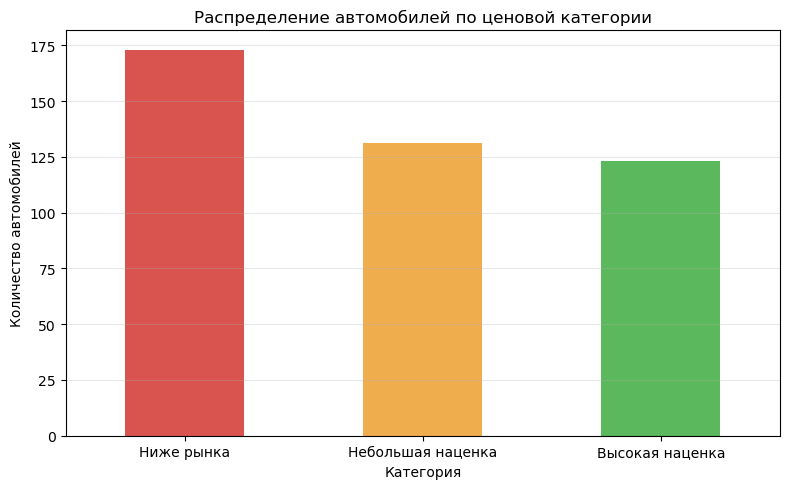

In [34]:
import matplotlib.pyplot as plt

category_counts = df["margin_category"].value_counts()

plt.figure(figsize=(8, 5))

category_counts.plot(
    kind="bar",
    color=["#d9534f", "#f0ad4e", "#5cb85c"]
)

plt.title("Распределение автомобилей по ценовой категории")
plt.xlabel("Категория")
plt.ylabel("Количество автомобилей")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# ТОП-10 автомобилей с максимальной положительной скрытой маржой

top_10_margin = (
    df[df["hidden_margin_currency"] > 0]
    .sort_values("hidden_margin_currency", ascending=False)
    [
        [
            "title",
            "price_usd",
            "supplier_price",
            "hidden_margin_currency",
            "hidden_margin_percent"
        ]
    ]
    .head(10)
)

display(top_10_margin)

,title,price_usd,supplier_price,hidden_margin_currency,hidden_margin_percent
229,Porsche Panamera,240555.56,70370.370,170185.190,241.842113
224,Porsche Panamera,231481.48,70370.370,161111.110,228.947368
6,Mercedes-Benz G 63 AMG,342592.59,187870.375,154722.215,82.355834
289,Porsche Panamera,218518.52,70370.370,148148.150,210.526320
132,Mercedes-Benz G 500,175925.93,28240.740,147685.190,522.950850
185,Mercedes-Benz G 63 AMG,324074.07,187870.375,136203.695,72.498761
317,Porsche Taycan,222222.22,87962.960,134259.260,152.631585
84,Mercedes-Benz S 450,236111.11,106481.480,129629.630,121.739132
327,Porsche Cayenne,138888.89,15740.740,123148.150,782.352990
281,Porsche 911 GT3,412962.96,294444.445,118518.515,40.251571


In [36]:
potential_savings = df.loc[
    df["hidden_margin_currency"] > 0,
    "hidden_margin_currency"
].sum()

positive_margin_count = (
    df["hidden_margin_currency"] > 0
).sum()

print(
    f"Потенциальная экономия: ${potential_savings:,.2f}"
)

print(
    f"Автомобилей с положительной маржой: {positive_margin_count}"
)

Потенциальная экономия: $4,806,897.61
Автомобилей с положительной маржой: 172


In [37]:
total_cars = len(df)

positive_margin_share = (
    positive_margin_count / total_cars * 100
)

print(
    f"Доля автомобилей с положительной маржой: "
    f"{positive_margin_share:.2f}%"
)

Доля автомобилей с положительной маржой: 40.28%


In [38]:
# ==============================
# ФИНАЛЬНЫЕ KPI ПРОЕКТА
# ==============================

total_cars = len(df)

positive_margin = df[df["hidden_margin_currency"] > 0]

positive_cars = len(positive_margin)

potential_savings = positive_margin["hidden_margin_currency"].sum()

high_margin = df[df["margin_category"] == "Высокая наценка"]

high_margin_cars = len(high_margin)

high_margin_total = high_margin["hidden_margin_currency"].sum()

average_margin = df["hidden_margin_percent"].mean()


print("========== ФИНАЛЬНЫЕ KPI ==========")
print(f"Всего автомобилей: {total_cars}")
print(f"Автомобилей с положительной маржой: {positive_cars}")
print(f"Потенциальная экономия: ${potential_savings:,.2f}")
print(f"Автомобилей с высокой наценкой: {high_margin_cars}")
print(f"Маржа высокой наценки: ${high_margin_total:,.2f}")
print(f"Средняя скрытая наценка: {average_margin:.2f}%")

========== ФИНАЛЬНЫЕ KPI ==========
Всего автомобилей: 427
Автомобилей с положительной маржой: 172
Потенциальная экономия: $4,806,897.61
Автомобилей с высокой наценкой: 123
Маржа высокой наценки: $4,548,341.32
Средняя скрытая наценка: 27.70%


In [39]:
# ==============================
# ИТОГОВАЯ ТАБЛИЦА KPI
# ==============================

kpi_table = pd.DataFrame({
    "Метрика": [
        "Всего автомобилей",
        "Автомобилей с положительной маржой",
        "Потенциальная экономия",
        "Автомобилей с высокой наценкой",
        "Маржа высокой наценки",
        "Средняя скрытая наценка"
    ],
    
    "Значение": [
        total_cars,
        positive_cars,
        f"${potential_savings:,.2f}",
        high_margin_cars,
        f"${high_margin_total:,.2f}",
        f"{average_margin:.2f}%"
    ]
})

display(kpi_table)

,Метрика,Значение
0,Всего автомобилей,427
1,Автомобилей с положительной маржой,172
2,Потенциальная экономия,"$4,806,897.61"
3,Автомобилей с высокой наценкой,123
4,Маржа высокой наценки,"$4,548,341.32"
5,Средняя скрытая наценка,27.70%


In [40]:
# ==========================================
# АНАЛИЗ ПО БРЕНДАМ
# ==========================================

df["brand"] = df["title"].str.split().str[0]

brand_analysis = (
    df.groupby("brand")
      .agg(
          cars_count=("title", "count"),
          positive_margin_cars=(
              "hidden_margin_currency",
              lambda x: (x > 0).sum()
          ),
          total_hidden_margin=(
              "hidden_margin_currency",
              "sum"
          ),
          average_margin_percent=(
              "hidden_margin_percent",
              "mean"
          )
      )
      .reset_index()
)

brand_analysis = brand_analysis.sort_values(
    "total_hidden_margin",
    ascending=False
)

display(brand_analysis)

,brand,cars_count,positive_margin_cars,total_hidden_margin,average_margin_percent
2,Porsche,200,89,2065827.72,40.831494
1,Mercedes-Benz,200,74,702111.98,18.509302
0,Maserati,27,9,-32962.98,-1.512185


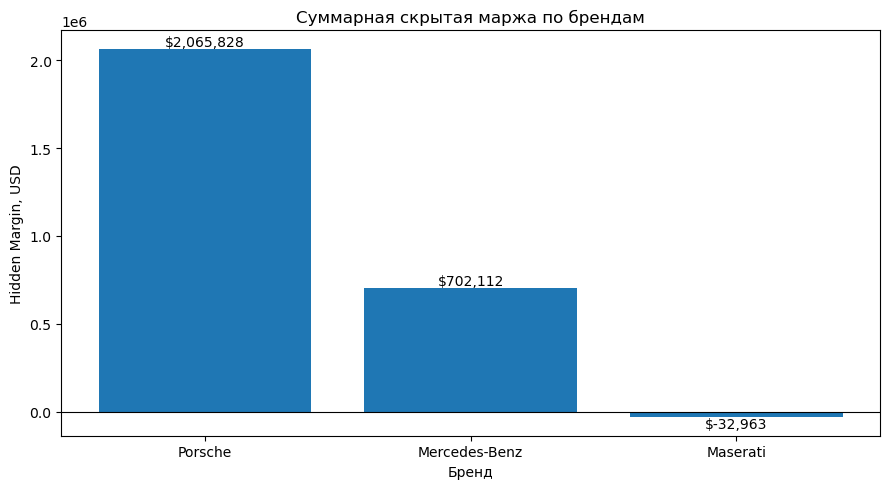

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

bars = plt.bar(
    brand_analysis["brand"],
    brand_analysis["total_hidden_margin"]
)

plt.title("Суммарная скрытая маржа по брендам")
plt.xlabel("Бренд")
plt.ylabel("Hidden Margin, USD")

plt.axhline(0, color="black", linewidth=0.8)

for bar in bars:
    value = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

In [42]:
# ==========================================
# РАСПРЕДЕЛЕНИЕ АВТОМОБИЛЕЙ ПО КАТЕГОРИЯМ
# ==========================================

margin_counts = df["margin_category"].value_counts()

print(margin_counts)

margin_category
Ниже рынка           173
Небольшая наценка    131
Высокая наценка      123
Name: count, dtype: int64


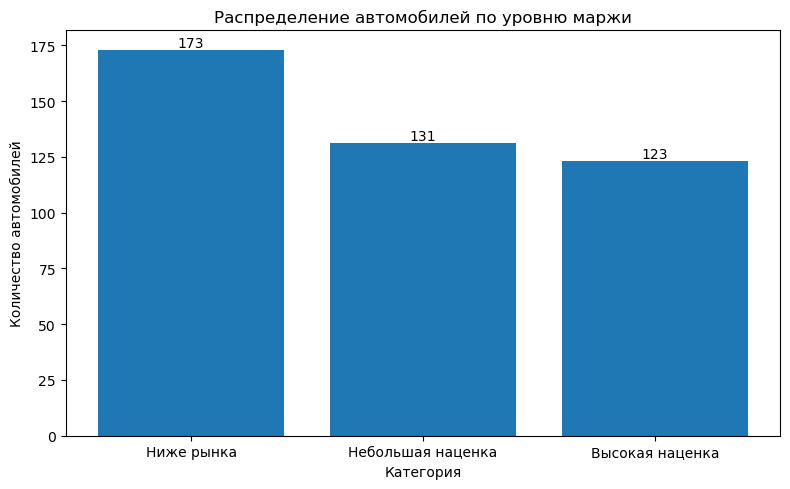

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    margin_counts.index,
    margin_counts.values
)

plt.title("Распределение автомобилей по уровню маржи")
plt.xlabel("Категория")
plt.ylabel("Количество автомобилей")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

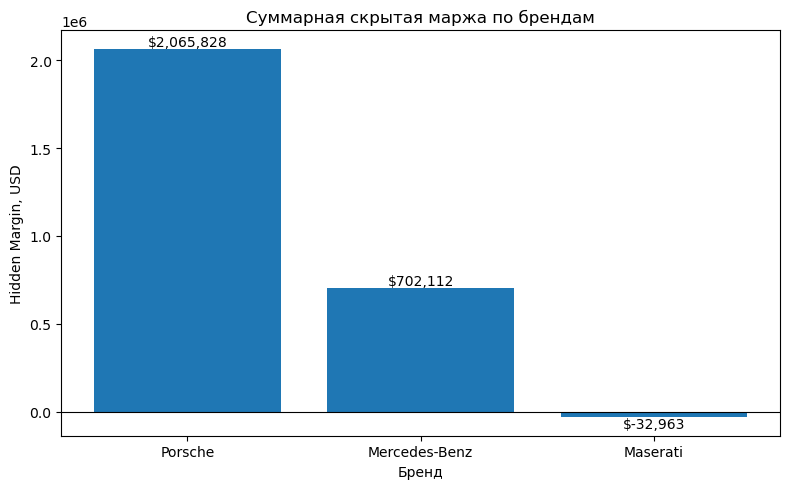

In [44]:
# ==========================================
# СКРЫТАЯ МАРЖА ПО БРЕНДАМ
# ==========================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    brand_analysis["brand"],
    brand_analysis["total_hidden_margin"]
)

plt.title("Суммарная скрытая маржа по брендам")
plt.xlabel("Бренд")
plt.ylabel("Hidden Margin, USD")

plt.axhline(0, color="black", linewidth=0.8)

for bar in bars:
    value = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

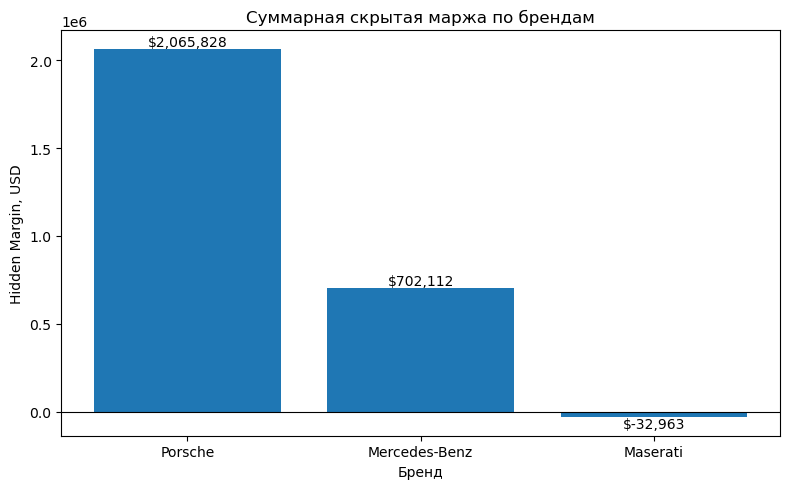

In [45]:
# ==========================================
# СКРЫТАЯ МАРЖА ПО БРЕНДАМ
# ==========================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    brand_analysis["brand"],
    brand_analysis["total_hidden_margin"]
)

plt.title("Суммарная скрытая маржа по брендам")
plt.xlabel("Бренд")
plt.ylabel("Hidden Margin, USD")

plt.axhline(0, color="black", linewidth=0.8)

for bar in bars:
    value = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

In [46]:
# ==========================================
# ФИНАЛЬНЫЙ DATASET ДЛЯ LOOKER STUDIO
# ==========================================

final_columns = [
    "title",
    "price_usd",
    "supplier_price",
    "hidden_margin_currency",
    "hidden_margin_percent",
    "margin_category"
]

# Проверяем, что все необходимые колонки существуют
missing_columns = [
    col for col in final_columns
    if col not in df.columns
]

if missing_columns:
    print("Не хватает колонок:", missing_columns)
else:
    looker_df = df[final_columns].copy()

    # Добавляем бренд из названия автомобиля
    looker_df["brand"] = looker_df["title"].apply(
        lambda x:
        "Mercedes-Benz" if str(x).startswith("Mercedes-Benz")
        else "Porsche" if str(x).startswith("Porsche")
        else "Maserati" if str(x).startswith("Maserati")
        else "Other"
    )

    # Сохраняем CSV
    looker_df.to_csv(
        "final_auto_analysis.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("CSV успешно создан!")
    print("Количество строк:", len(looker_df))
    print("Колонки:")
    print(looker_df.columns.tolist())

    display(looker_df.head(10))

CSV успешно создан!
Количество строк: 427
Колонки:
['title', 'price_usd', 'supplier_price', 'hidden_margin_currency', 'hidden_margin_percent', 'margin_category', 'brand']


,title,price_usd,supplier_price,hidden_margin_currency,hidden_margin_percent,margin_category,brand
0,Mercedes-Benz E 200,20370.37,11759.260,8611.110,73.228332,Высокая наценка,Mercedes-Benz
1,Mercedes-Benz G 500,22222.22,28240.740,-6018.520,-21.311481,Ниже рынка,Mercedes-Benz
2,Mercedes-Benz V 250 Avantgarde,70166.67,108518.520,-38351.850,-35.341295,Ниже рынка,Mercedes-Benz
3,Mercedes-Benz E 300,35555.56,9907.405,25648.155,258.878637,Высокая наценка,Mercedes-Benz
4,Mercedes-Benz E 350,13888.89,13888.890,0.000,0.000000,Небольшая наценка,Mercedes-Benz
5,Mercedes-Benz E 320,6111.11,6481.480,-370.370,-5.714281,Ниже рынка,Mercedes-Benz
6,Mercedes-Benz G 63 AMG,342592.59,187870.375,154722.215,82.355834,Высокая наценка,Mercedes-Benz
7,Mercedes-Benz S 500,10185.19,10185.190,0.000,0.000000,Небольшая наценка,Mercedes-Benz
8,Mercedes-Benz GLE Coupe 450 AMG,40740.74,61481.480,-20740.740,-33.734939,Ниже рынка,Mercedes-Benz
9,Mercedes-Benz E 350,17592.59,13888.890,3703.700,26.666638,Высокая наценка,Mercedes-Benz


In [47]:
looker_df["positive_margin"] = (
    looker_df["hidden_margin_currency"] > 0
).astype(int)

looker_df["high_margin"] = (
    looker_df["margin_category"] == "Высокая наценка"
).astype(int)

In [48]:
looker_df.to_csv(
    "final_auto_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Финальный CSV обновлён.")

Финальный CSV обновлён.
